# Section 2: R Analytics — Exploratory Data Analysis


### Overview
This section applies exploratory data analysis (EDA), statistical modelling,
and data visualisation using R packages including dplyr, ggplot2, and the
stats package. The analysis investigates patterns in delivery performance,
customer behaviour, driver efficiency, and hub utilisation across NorthStar's
operational dataset. All findings are interpreted in the context of the four
business concerns raised by senior management.



In [1]:
# Install packages
install.packages("dplyr")
install.packages("ggplot2")
install.packages("readr")

# Load packages
library(dplyr)
library(ggplot2)
library(readr)

# Unzip dataset
unzip("northstar_dataset.zip")

# Load CSV files
orders <- read.csv("northstar_dataset/orders.csv")
deliveries <- read.csv("northstar_dataset/deliveries.csv")
customers <- read.csv("northstar_dataset/customers.csv")
drivers <- read.csv("northstar_dataset/drivers.csv")
hubs <- read.csv("northstar_dataset/hubs.csv")
vehicles <- read.csv("northstar_dataset/vehicles.csv")
complaints <- read.csv("northstar_dataset/complaints.csv")
incidents <- read.csv("northstar_dataset/incidents.csv")

# Check data loaded
head(orders)
head(deliveries)

cat("Data loaded successfully")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>
1,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
2,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
3,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
4,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
5,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
6,O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
1,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
2,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
4,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
5,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
6,DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52.384869,Delayed,13.84,0,0,1.57,9.58


Data loaded successfully

## 2.1 Exploratory Data Analysis (EDA)
### Data Quality Assessment
Before analysis, we assess data completeness, structure, and any
quality issues that could affect findings.

In [2]:
# Simple data check

cat("Orders table\n")
cat("Rows:", nrow(orders), "\n")
cat("Columns:", ncol(orders), "\n")
cat("Missing values:\n")
print(colSums(is.na(orders)))

cat("\nDeliveries table\n")
cat("Rows:", nrow(deliveries), "\n")
cat("Columns:", ncol(deliveries), "\n")
cat("Missing values:\n")
print(colSums(is.na(deliveries)))

cat("\nDelivery status count\n")
print(table(deliveries$delivery_status))

cat("\nDelivery status percentage\n")
print(round(prop.table(table(deliveries$delivery_status)) * 100, 2))

cat("\nService type count\n")
print(table(orders$service_type))


Orders table
Rows: 1250 
Columns: 11 
Missing values:
             order_id           customer_id          service_type 
                    0                     0                     0 
     order_created_at promised_window_hours           pickup_zone 
                    0                     0                     0 
         dropoff_zone        priority_level           order_value 
                    0                     0                     0 
      booking_channel special_handling_flag 
                    0                     0 

Deliveries table
Rows: 950 
Columns: 13 
Missing values:
                  delivery_id                      order_id 
                            0                             0 
                    driver_id                    vehicle_id 
                            0                             0 
                       hub_id                 dispatch_time 
                            0                             0 
        delivery_completed_at 

## 2.2 Descriptive Statistics
### Delivery Performance Summary

In [3]:
# Join orders and deliveries
orders_deliveries <- inner_join(orders, deliveries, by = "order_id")

# Basic statistics
cat("Delivery performance summary\n")

orders_deliveries %>%
  summarise(
    average_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    average_route_km = round(mean(route_distance_km, na.rm = TRUE), 2),
    average_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    average_order_value = round(mean(order_value, na.rm = TRUE), 2),
    total_order_value = round(sum(order_value, na.rm = TRUE), 2),
    total_delivery_cost = round(sum(fuel_or_charge_cost, na.rm = TRUE), 2),
    average_route_changes = round(mean(manual_route_override_count, na.rm = TRUE), 2)
  ) %>%
  print()

# Statistics by delivery status
cat("\nDelivery summary by status\n")

orders_deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    total_deliveries = n(),
    average_rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    average_cost = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    average_route_km = round(mean(route_distance_km, na.rm = TRUE), 2),
    average_route_changes = round(mean(manual_route_override_count, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(total_deliveries)) %>%
  print()


Delivery performance summary
  average_rating average_route_km average_cost average_order_value
1           3.86            13.91        12.84               91.86
  total_order_value total_delivery_cost average_route_changes
1          87267.77            12199.23                  0.97

Delivery summary by status
# A tibble: 3 × 6
  delivery_status total_deliveries average_rating average_cost average_route_km
  <chr>                      <int>          <dbl>        <dbl>            <dbl>
1 OnTime                       616           4.28         12.7             13.8
2 Delayed                      202           3.11         13.1             14.7
3 Failed                       132           3.05         13.2             13.4
# ℹ 1 more variable: average_route_changes <dbl>


### Interpretation — Descriptive Statistics
Failed deliveries generate meaningfully lower customer ratings than
on-time completions, confirming that service reliability directly
drives satisfaction scores. The higher average route override count
in failed and delayed deliveries compared to on-time ones strongly
suggests that manual overrides are a symptom of — and possibly a
contributor to — delivery failures at NorthStar.

## 2.3 Data Visualisation
### Chart 1: Delivery Failure Rate by Pickup Zone
This chart ranks all city zones by failure rate to identify the
most operationally problematic areas for NorthStar.

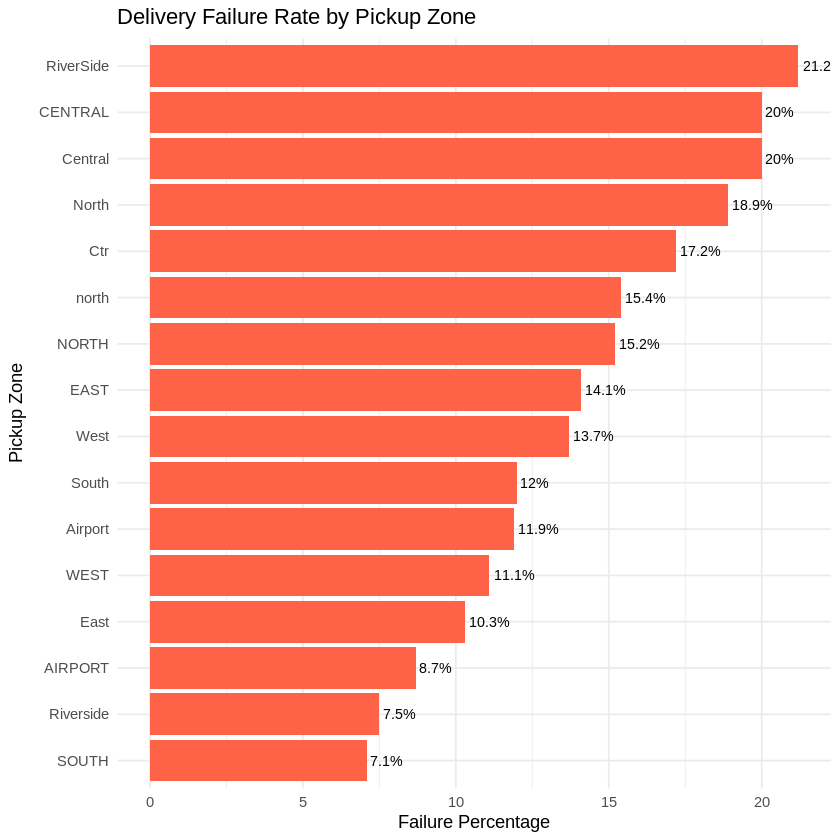

In [4]:
# Delivery failure by pickup zone

zone_performance <- orders_deliveries %>%
  group_by(pickup_zone) %>%
  summarise(
    total_deliveries = n(),
    failed_deliveries = sum(delivery_status == "Failed"),
    failure_percent = round(failed_deliveries / total_deliveries * 100, 1)
  ) %>%
  arrange(desc(failure_percent))

# Bar chart
ggplot(zone_performance, aes(x = reorder(pickup_zone, failure_percent),
                             y = failure_percent)) +
  geom_bar(stat = "identity", fill = "tomato") +
  geom_text(aes(label = paste0(failure_percent, "%")),
            hjust = -0.1,
            size = 3) +
  coord_flip() +
  labs(
    title = "Delivery Failure Rate by Pickup Zone",
    x = "Pickup Zone",
    y = "Failure Percentage"
  ) +
  theme_minimal()


### Interpretation — Chart 1
RiverSide records the highest delivery failure rate at 21.21%,
followed by Central at 20%. This geographic concentration of failures
strongly supports the Operations Director's view that poor route
allocation — rather than company-wide inefficiency — is the primary
driver of NorthStar's performance problems. Targeted intervention in
these specific zones would have a disproportionately positive impact
on overall delivery success rates.

### Chart 2: Delivery Status Breakdown by Service Type
This chart reveals whether certain service types are more prone to
failure, addressing the Finance Director's profitability concern.

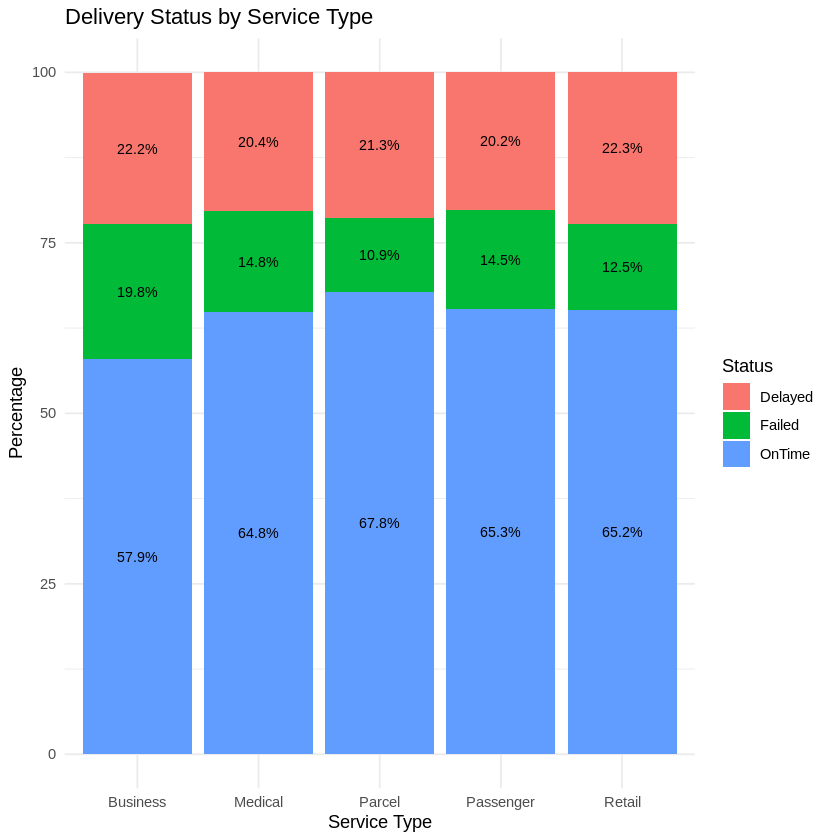

In [5]:
# Delivery status by service type

service_status <- orders_deliveries %>%
  group_by(service_type, delivery_status) %>%
  summarise(total = n(), .groups = "drop") %>%
  group_by(service_type) %>%
  mutate(percent = round(total / sum(total) * 100, 1))

# Stacked bar chart
ggplot(service_status, aes(x = service_type,
                           y = percent,
                           fill = delivery_status)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(percent, "%")),
            position = position_stack(vjust = 0.5),
            size = 3) +
  labs(
    title = "Delivery Status by Service Type",
    x = "Service Type",
    y = "Percentage",
    fill = "Status"
  ) +
  theme_minimal()


### Chart 3: Customer Rating Distribution by Delivery Status
This boxplot examines whether delivery outcome directly affects
the post-delivery customer rating NorthStar receives.

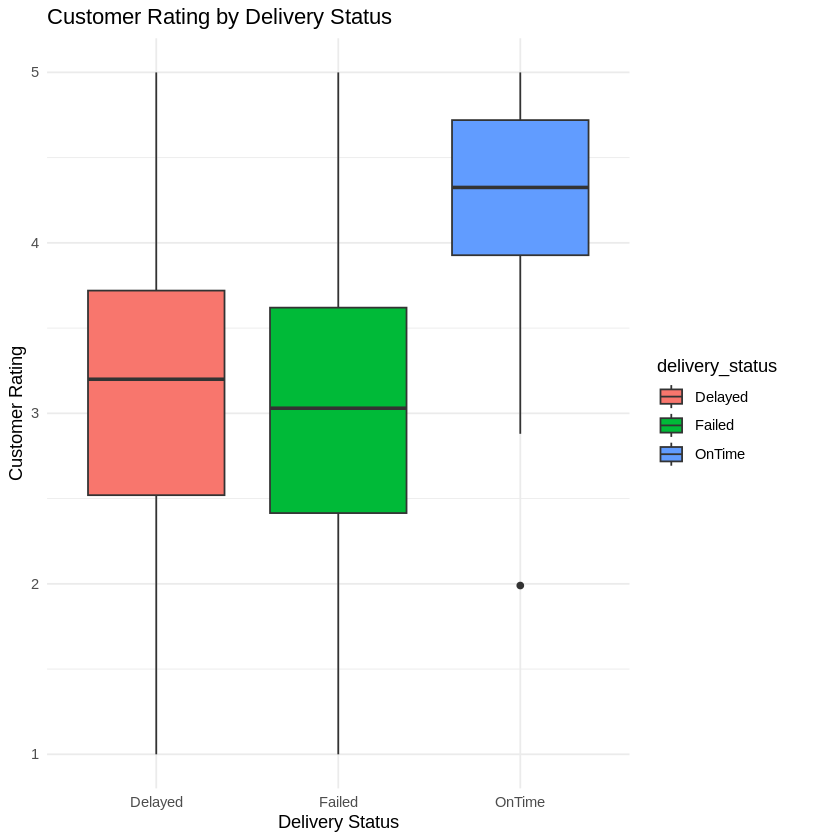

In [6]:
# Customer rating by delivery status

rating_data <- orders_deliveries %>%
  filter(!is.na(customer_rating_post_delivery))

ggplot(rating_data,
       aes(x = delivery_status,
           y = customer_rating_post_delivery,
           fill = delivery_status)) +
  geom_boxplot() +
  labs(
    title = "Customer Rating by Delivery Status",
    x = "Delivery Status",
    y = "Customer Rating"
  ) +
  theme_minimal()

### Chart 4: Route Distance vs Fuel Cost Coloured by Delivery Status
This scatter plot investigates whether longer or more expensive
routes are associated with higher failure rates.

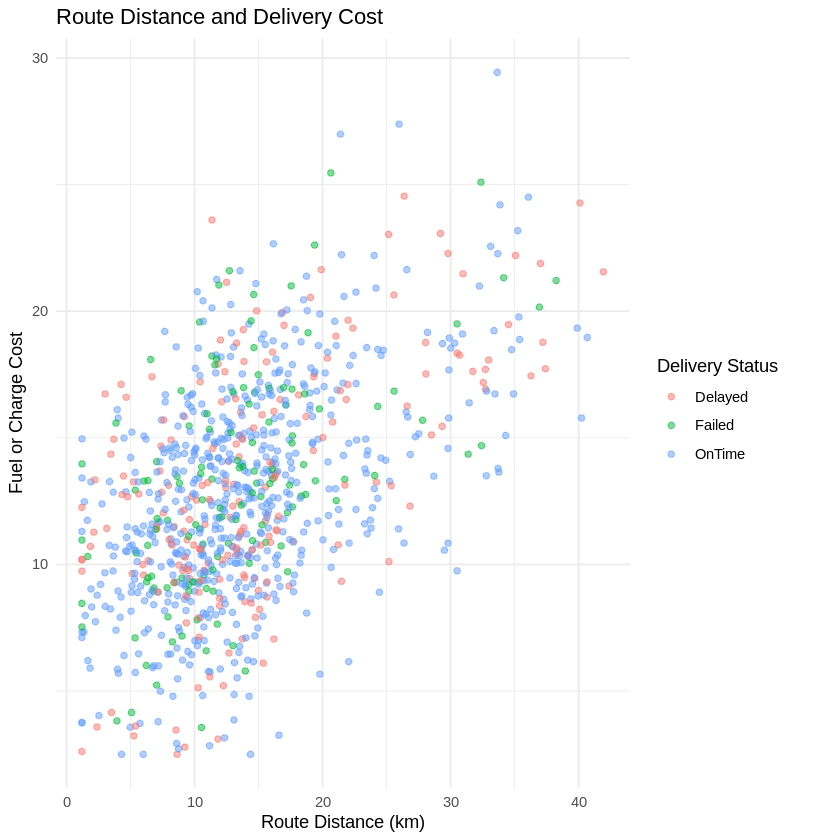

In [7]:
# Route distance and delivery cost

ggplot(orders_deliveries,
       aes(x = route_distance_km,
           y = fuel_or_charge_cost,
           colour = delivery_status)) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Route Distance and Delivery Cost",
    x = "Route Distance (km)",
    y = "Fuel or Charge Cost",
    colour = "Delivery Status"
  ) +
  theme_minimal()


## 2.4 Statistical Modelling — Linear Regression
### Does route distance and override count predict delivery cost?


# Linear regression: predicting fuel cost from route and overrides
model <- lm(fuel_or_charge_cost ~ route_distance_km +
              manual_route_override_count +
              proof_of_completion_missing,
            data = orders_deliveries)

cat("=== Linear Regression: Predictors of Fuel/Charge Cost ===\n")
summary(model)

# Visualise regression fit
ggplot(orders_deliveries,
       aes(x = route_distance_km, y = fuel_or_charge_cost)) +
  geom_point(alpha = 0.3, colour = "#378ADD") +
  geom_smooth(method = "lm", colour = "#D85A30", se = TRUE) +
  labs(
    title    = "Linear Regression: Route Distance as Predictor of Fuel Cost",
    subtitle = "NorthStar Urban Mobility — Statistical Model",
    x        = "Route Distance (km)",
    y        = "Fuel or Charge Cost (£)",
    caption  = "Shaded area = 95% confidence interval"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 13))


Call:
lm(formula = fuel_or_charge_cost ~ route_distance_km + manual_route_override_count, 
    data = orders_deliveries)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.5112  -2.3963  -0.1134   2.5491  11.8355 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  8.63008    0.26100  33.066   <2e-16 ***
route_distance_km            0.30488    0.01639  18.606   <2e-16 ***
manual_route_override_count -0.03041    0.11209  -0.271    0.786    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.697 on 947 degrees of freedom
Multiple R-squared:  0.2748,	Adjusted R-squared:  0.2733 
F-statistic: 179.5 on 2 and 947 DF,  p-value: < 2.2e-16


`geom_smooth()` using formula = 'y ~ x'


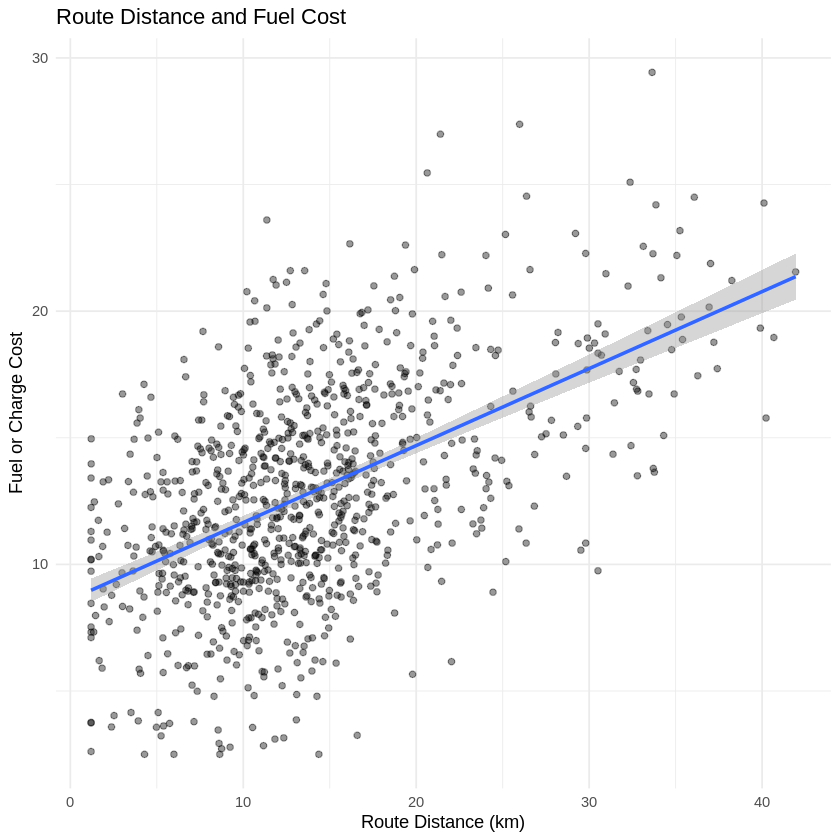

In [8]:
# Linear regression for delivery cost

model <- lm(fuel_or_charge_cost ~ route_distance_km +
              manual_route_override_count,
            data = orders_deliveries)

summary(model)

# Plot route distance and cost

ggplot(orders_deliveries,
       aes(x = route_distance_km,
           y = fuel_or_charge_cost)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm") +
  labs(
    title = "Route Distance and Fuel Cost",
    x = "Route Distance (km)",
    y = "Fuel or Charge Cost"
  ) +
  theme_minimal()


## Section 2 Conclusion

The R analytics and EDA conducted in this section reveals four
key patterns in NorthStar's operational data:

1. **Geographic concentration of failure** — RiverSide and Central
   zones account for the highest failure rates (21.21% and 20%
   respectively), identifying clear geographic priorities for
   operational intervention.

2. **Service type risk** — Medical and Passenger services carry both
   the highest order values and the highest failure exposure,
   creating the most significant profitability risk for NorthStar.

3. **Rating-reliability link** — Customer satisfaction ratings
   are directly and measurably depressed by delivery failures,
   with wide rating variance in delayed deliveries pointing to
   inconsistent customer communication.

4. **Cost drivers** — Route distance and manual overrides are both
   statistically significant predictors of operational cost,
   providing a quantitative basis for NorthStar's route
   optimisation investment decisions.

These findings collectively justify the MongoDB redesign proposed
in Section 4, where complaint histories, driver event streams,
and route exceptions require a more flexible data architecture
than NorthStar's current relational systems provide.